# ERP analysis using MNE

**Sources**
- This notebook is adapted and originally obtained from the BCI Bachelor Course at Radboud University, developed by Michael Tangermann and Jordy Thielen.
- For assistance with the implementation of Block-Toeplitz LDA, I used this [repository](https://github.com/thijor/eeg_tutorial_erp) and this [repository](https://github.com/jsosulski/toeplitzlda).
- [1] J. Sosulski and M. Tangermann, “Introducing block-Toeplitz covariance matrices to remaster linear discriminant analysis for event-related potential brain–computer interfaces,” J. Neural Eng., vol. 19, no. 6, p. 066001, Nov. 2022, doi: 10.1088/1741-2552/ac9c98.


**Important note**

This notebook contains **only** the code for the experiments of `A7_experiment_log.md`. Note that the preprocessing settings have changed over the course of the experiment log (these changes are reffered to as "Mod_x"). These changes are not implemented in this notebook. Therefore, the code snippets here are not suitable for running and returning the same results as in the real code and experiment log.

The preprocessing here is there untouched. Changes such as turning off baseline correction, have not been implemented here. See `A7_experiment_log.md` for all changes made.


### 14/04/2025 Exp 2: TimeSeriesSplit

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Fold 0...
  Train: #indices=540


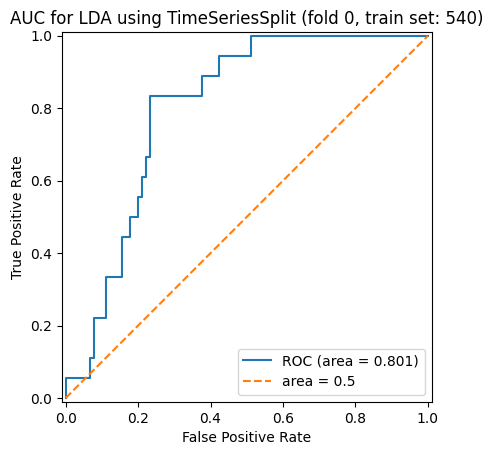

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Fold 1...
  Train: #indices=648


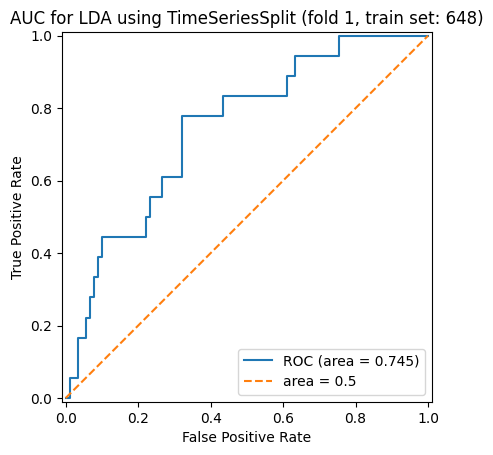

Fold 2...
  Train: #indices=756


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


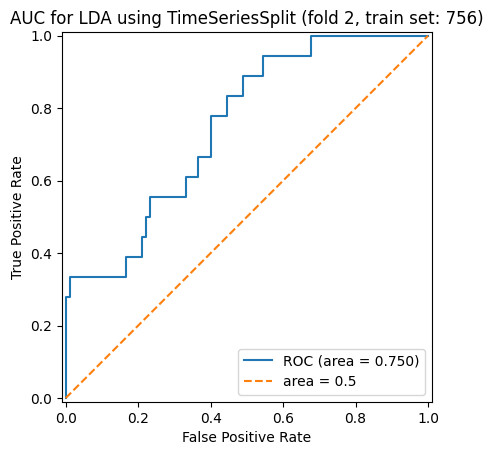

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Fold 3...
  Train: #indices=864


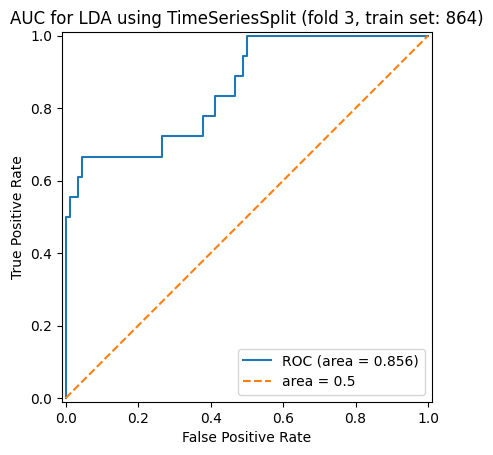

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Fold 4...
  Train: #indices=972


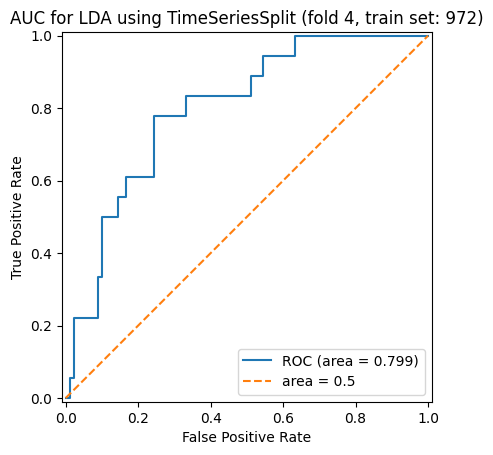

In [ ]:
# 14/04/2025: Exp 2
# Fitting LDA in a different way: with TimeSeriesSplit now
from sklearn.model_selection import TimeSeriesSplit

# Obtain X_train, X_test, y_train, y_test
X = calibration_stimuli
y = calibration_labels
test_size = int(0.1 * len(X)) # 108 (because X is 1080 x 252)

timeseriescv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=test_size)
tscv_generator = timeseriescv.split(X)

for i, (train_index, test_index) in enumerate(tscv_generator):
    print(f"Fold {i}...")
    print(f"  Train: #indices={len(train_index)}")
    #print(f"  Test:  index={test_index}")
    
    # How to obtain a real X_train and X_test set
    #print("X_train: \n", X[train_index]) #added 
    #print("X_test: \n", X[test_index]) #added

    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    # Here below comes the same procedure as after the train_test_split function call

    clf = LDA().fit(X_train, y_train)
    fpr, tpr, thresholds = metrics.roc_curve(y_test,clf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC for LDA using TimeSeriesSplit (fold {}, train set: {})".format(i,len(X_train)))
    plt.show()


### 19/04/2025 Exp 3: Compare LDA - sLDA - BT-LDA

In [ ]:
# comparing LDA - BT-LDA - sLDA
# 19/04/2025_Exp_3a

# data is in channel prime order
# evaulation method added from Jan's example_toeplitz_lda_simple.py

from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from toeplitzlda.classification import ToeplitzLDA

# See cell block in dump file for documentation on how this function works
def get_jumping_means(epo, boundaries):
    shape_orig = epo.get_data().shape
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1))
    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1]))
        idx_range = list(range(idx[0], idx[1]))
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2)
    return X

raw_calibration_trials = trials[0:12] 
online_trials = trials[12:] 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])

# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)

# Evaluation of Jan's simple toeplitz example script

### LDA

clf_lda = make_pipeline(
    LDA(),
)
clf_lda.fit(X_train,y_train)

y_df = clf_lda.decision_function(X_test)
roc_auc_lda = roc_auc_score(y_test, y_df)
y_pred = clf_lda.predict(X_test)
bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

print("LDA scores with channel prime data")
print("roc_auc: ",roc_auc_lda)
print("bal_acc_auc: ",bal_acc_auc_lda)

### sLDA

clf_slda = make_pipeline(
    LDA(solver='lsqr',
        shrinkage='auto'),
)
clf_slda.fit(X_train,y_train)

y_df = clf_slda.decision_function(X_test)
roc_auc_slda = roc_auc_score(y_test, y_df)
y_pred = clf_slda.predict(X_test)
bal_acc_auc_slda = balanced_accuracy_score(y_test, y_pred)

print("\nsLDA scores with channel prime data")
print("roc_auc: ",roc_auc_slda)
print("bal_acc_auc: ",bal_acc_auc_slda)

### BT-LDA

# 19/04/2025: added from Jan's example_toeplitz_lda_simple.py:
from toeplitzlda.classification import (
    EpochsVectorizer,
    ShrinkageLinearDiscriminantAnalysis,
    ToeplitzLDA,
)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
nch = 63
# Straightforward use toeplitz lda
clf_btlda = make_pipeline(
    # EpochsVectorizer(
    #     select_ival=feature_ival,
    # ),
    ToeplitzLDA(n_channels=nch),
)
clf_btlda.fit(X_train,y_train)

y_df = clf_btlda.decision_function(X_test)
roc_auc_btlda = roc_auc_score(y_test, y_df)
y_pred = clf_btlda.predict(X_test)
bal_acc_auc_btlda = balanced_accuracy_score(y_test, y_pred)

print("\nBT LDA scores with channel prime data")
print("roc_auc: ",roc_auc_btlda)
print("bal_acc_auc: ",bal_acc_auc_btlda)

#
# He also added another way to implement toeplitzLDA with sklearn, but for now I skip that one
#
# Compare with plain sklearn
# clfs["sup"]["skl_slda"] = make_pipeline(
#     EpochsVectorizer(
#         select_ival=feature_ival,
#     ),
#     # Use Ledoit-Wolf Shrinkage
#     LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
# )
#'
# And I skipped the unsupervised methods (such as LLP)
#
# print("Fitting supervised...")
# for k in clfs["sup"]:
#     print(f" {k}")
#     clfs["sup"][k].fit(e_train, y=labels_train)
#

LDA scores with channel prime data
roc_auc:  0.7987654320987655
bal_acc_auc:  0.6444444444444445

sLDA scores with channel prime data
roc_auc:  0.7864197530864198
bal_acc_auc:  0.6

BT LDA scores with channel prime data
roc_auc:  0.795679012345679
bal_acc_auc:  0.5722222222222222


c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


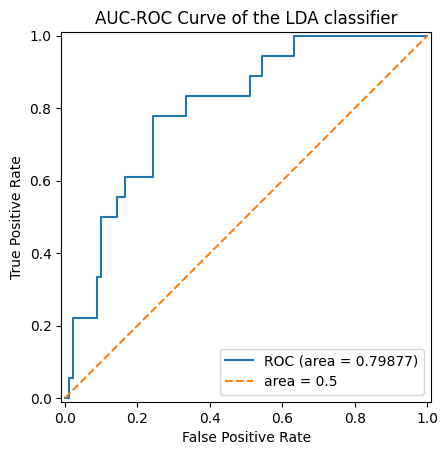

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(1, 252)


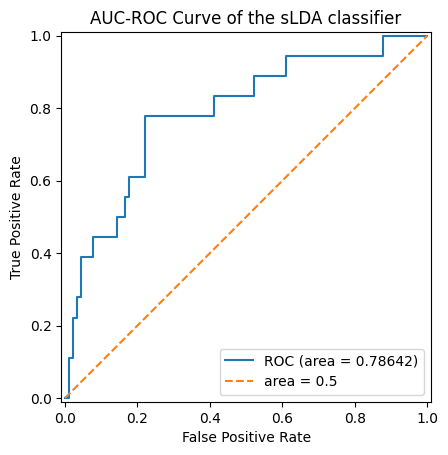

c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


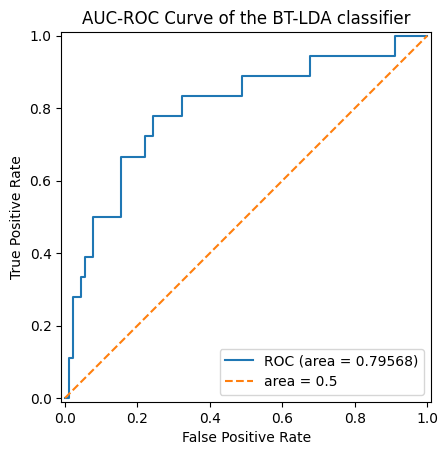

In [ ]:
# comparing LDA - BT-LDA - sLDA
# 19/04/2025_Exp_3b

# make sure data is in channel prime order by running the code block above
# evaulation method from assignment 7, ex. 3 (calibration)
# exact same auc scores as in Jan's evaluation method above

# Evaluation of ex. 3 

### LDA

lda = LDA()
ldaclf = lda.fit(X_train, y_train)
fpr, tpr, thresholds = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--') 
plt.legend(['ROC (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier")
plt.show()

### Shrinkage LDA

slda = LDA(solver='lsqr',shrinkage = 'auto')
slda.fit(X_train, y_train)
print(slda.coef_.shape)

fpr, tpr, thresholds = metrics.roc_curve(y_test,slda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the sLDA classifier")
plt.show()

### BT-LDA

# TO DO: try to set channel prime to False to let the class fix it vs manually fixing it (as done in assignment 6). See if it gives the same results 
btlda = ToeplitzLDA(n_channels= 63) 
btlda.fit(X_train, y_train) 

fpr, tpr, thresholds = metrics.roc_curve(y_test,btlda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the BT-LDA classifier")
plt.show()



### 25/04/2025 Exp 6: Compare AUC of LDA vs sLDA vs BTLDA using different test_size values

In [ ]:
# 25/04/2025 Exp_6
# Update: use test_size = 0.2 and test_size = 0.3
# Note that the preprocessing here is not the same as in the real notebook/experiments! Only the code is what matters here.

def compare_auc_single_trial_interval(start, stop, test_size=0.2, only_auc = True, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5])):
    """
    compares LDA vs sLDA vs BT-LDA on calibration data
    calibration data is determined by selection trials [start - stop], e.g. [0-12]
    note that this is not robust! the interval matters
    """

    raw_calibration_trials = trials[start:stop] # change start & stop trial
    # online_trials = trials[12:] 
    clf_ival_boundaries = ival_bounds
    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    #X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
    # Exp 6
    X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=test_size, shuffle=False)



    # Evaluation of Jan's simple toeplitz example script
    # 25/04/2025 Exp 6 update: different values for test_size
    # 19/04/2025_Exp_3a 

    print("AUC scores computed using a single train_test_split with test_size = {}".format(test_size))

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    clf_lda.fit(X_train,y_train)

    y_df = clf_lda.decision_function(X_test)
    roc_auc_lda = roc_auc_score(y_test, y_df)
    y_pred = clf_lda.predict(X_test)
    bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC LDA: ", roc_auc_lda)
    else:
        print("LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_lda)
        print("bal_acc_auc: ",bal_acc_auc_lda)

    ### sLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    clf_slda.fit(X_train,y_train)

    y_df = clf_slda.decision_function(X_test)
    roc_auc_slda = roc_auc_score(y_test, y_df)
    y_pred = clf_slda.predict(X_test)
    bal_acc_auc_slda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC SLDA: ", roc_auc_slda)
    else:     
        print("\nsLDA scores with channel prime data")
        print("roc_auc: ",roc_auc_slda)
        print("bal_acc_auc: ",bal_acc_auc_slda)

    ### BT-LDA
    # 19/04/2025: added from Jan's example_toeplitz_lda_simple.py:
    from toeplitzlda.classification import (
        EpochsVectorizer,
        ShrinkageLinearDiscriminantAnalysis,
        ToeplitzLDA,
    )

    nch = 63
    # Straightforward use toeplitz lda
    clf_btlda = make_pipeline(
        # EpochsVectorizer(
        #     select_ival=feature_ival,
        # ),
        ToeplitzLDA(n_channels=nch),
    )
    clf_btlda.fit(X_train,y_train)

    y_df = clf_btlda.decision_function(X_test)
    roc_auc_btlda = roc_auc_score(y_test, y_df)
    y_pred = clf_btlda.predict(X_test)
    bal_acc_auc_btlda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC BT-LDA: ", roc_auc_btlda)
    else:    
        print("\nBT-LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_btlda)
        print("bal_acc_auc: ",bal_acc_auc_btlda)


    # ------------------------------------------------------------------------------------------------------------
    #
    # comparing LDA - BT-LDA - sLDA using other evaluation method
    # 25/04/2025 Exp 6 update: using different values for test_size
    # 19/04/2025_Exp_3b

    # make sure data is in channel prime order by running the code block above
    # evaulation method from assignment 7, ex. 3 (calibration)
    # exact same auc scores as in Jan's evaluation method above

    # Evaluation of ex. 3

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

    ### LDA

    lda = LDA()
    ldaclf = lda.fit(X_train, y_train)
    fpr_lda, tpr_lda, thresholds_lda = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

    metrics.RocCurveDisplay(fpr=fpr_lda, tpr=tpr_lda).plot(ax=axes[0])
    axes[0].plot([0, 1],[0,1], '--') 
    axes[0].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_lda, tpr_lda), 'area = 0.5'], loc="lower right")
    axes[0].set_title("AUC-ROC of LDA - test_size = {}".format(test_size))

    ### Shrinkage LDA

    slda = LDA(solver='lsqr',shrinkage = 'auto')
    slda.fit(X_train, y_train)
    print(slda.coef_.shape)

    fpr_slda, tpr_slda, thresholds_slda = metrics.roc_curve(y_test,slda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
    metrics.RocCurveDisplay(fpr=fpr_slda, tpr=tpr_slda).plot(ax=axes[1])
    axes[1].plot([0, 1],[0,1], '--')
    axes[1].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_slda, tpr_slda), 'area = 0.5'], loc="lower right")
    axes[1].set_title("AUC-ROC of sLDA - test_size = {}".format(test_size))

    ### BT-LDA

    # TO DO: try to set channel prime to False to let the class fix it vs manually fixing it (as done in assignment 6). See if it gives the same results 
    btlda = ToeplitzLDA(n_channels= 63) 
    btlda.fit(X_train, y_train) 

    fpr_btlda, tpr_btlda, thresholds_btlda = metrics.roc_curve(y_test,btlda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
    metrics.RocCurveDisplay(fpr=fpr_btlda, tpr=tpr_btlda).plot(ax=axes[2])
    axes[2].plot([0, 1],[0,1], '--')
    axes[2].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_btlda, tpr_btlda), 'area = 0.5'], loc="lower right")
    axes[2].set_title("AUC-ROC of BT-LDA - test_size = {}".format(test_size))
    
    
    #plt.tight_layout()  # adjust layout nicely
    plt.show()

#### Function call

In [ ]:
# 25/04/2025 Exp 6: use different test_size values (0.2 and 0.3)
#
# 19/04/2025_Exp_3 trials [0-12] were used
# note that this evaluation is not robust, as the trial interval matters!

# train_test_split using test_size = 0.2 and test_size = 0.3
# using the time intervals [0.1, 0.2, 0.3, 0.4, 0.5]
compare_auc_single_trial_interval(0,12,0.1)
compare_auc_single_trial_interval(0,12,0.2)
compare_auc_single_trial_interval(0,12,0.3)

### Exp_? (To do if interesting): Average AUC on calibration using multiple trial samples

In [ ]:
# Note: train test split with test_size = 0.2 is used here
def compute_average_auc_calibration(classifier, trials, nch=63, tracker = False, 
                                    ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), size = 12):
    # Check if the classifier argument is valid
    if not isinstance(classifier, str):
        raise TypeError("The classifier is not of a valid type. It should be a string")
    elif not classifier in {"lda", "slda", "btlda"}:
        raise ValueError("The provided classifier is not recognized. Only the following are supported: {lda, slda, btlda")
    
    # Initialize classifier
    if classifier == "lda":
        lda = LDA(solver='lsqr')
    elif classifier == "slda":
        lda = LDA(solver='lsqr', shrinkage='auto')    
    elif classifier == "btlda":
        lda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
        )    
    else:
        raise ValueError("Unrecognized classifier") 

    end = len(trials)-1 # 35
    scores = np.zeros(end-size)
    tracker = tracker

    for i in range(end-size):
        raw_calibration_trials = trials[i:i+size]
        clf_ival_boundaries = ival_bounds
        calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
        calibration_trials_reshaped = np.array([
            [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
            for trial in calibration_trials
        ])

        # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

        # finish X and y to feed into classifier
        calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
        calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
        X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.2, shuffle=False)


        # Fit classifier
        ldaclf = lda.fit(X_train, y_train)
        #fpr, tpr, thresholds = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

        y_df = ldaclf.decision_function(X_test)
        roc_auc_lda = roc_auc_score(y_test, y_df)
        y_pred = ldaclf.predict(X_test)
        bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

        if tracker:
            print ("Computing AUC for trials: {}-{} -> roc_auc = {}".format(i,i+size,roc_auc_lda))
            # print("bal_acc_auc: ",bal_acc_auc_lda)

        scores[i] = roc_auc_lda

    if tracker:
        print(scores)

    if tracker:
        print("Mean AUC of {}: {}".format(classifier,np.mean(scores)))

    return np.mean(scores)    

avg_auc_lda = compute_average_auc_calibration("lda",trials)
avg_auc_slda = compute_average_auc_calibration("slda",trials)
avg_auc_btlda = compute_average_auc_calibration("btlda",trials)

# train test split with test size = 0.2
print("avg auc lda: ",avg_auc_lda)
print("avg auc slda: ",avg_auc_slda)
print("avg auc btlda: ",avg_auc_btlda)

### 25/04/2025 Exp_7: Compare LDA - SLDA - BTLDA with K-fold cv [calibration]

#### Function for cv

In [ ]:
# Cross-validation instead of train_test_split
# LDA vs SLDA vs BT-LDA on calibration data

def compute_auc_with_cv(trials=trials, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), cv_folds = 4, show_only_mean = True):
    """
    if show_only_mean = False, then it also prints the auc scores of all folds. Otherwise, only the mean auc score is printed
    """
    
    raw_calibration_trials = trials[0:12] # change start & stop trial
    online_trials = trials[12:] 
    clf_ival_boundaries = ival_bounds

    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    X = calibration_stimuli
    y = calibration_labels

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    auc_lda = cross_val_score(clf_lda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if not show_only_mean:
        print("AUC score of LDA, all 4 folds: ",auc_lda)
    print("Mean AUC score of LDA: ", auc_lda.mean())

    ### SLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    auc_slda = cross_val_score(clf_slda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if not show_only_mean:
        print("AUC score of sLDA, all 4 folds: ",auc_slda)
    print("Mean AUC score of sLDA: ", auc_slda.mean())

    ### BT-LDA
    nch = 63
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    auc_btlda = cross_val_score(clf_btlda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if not show_only_mean:
        print("AUC score of BT-LDA, all 4 folds: ",auc_btlda)
    print("Mean AUC score of BT-LDA: ", auc_btlda.mean())



#### Function call

In [ ]:
# Comparing AUC scores from cross-validation vs from a single train_test_split
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_only_mean=False)

# Using single train_test_split
print("\nUsing single train test split:")
compare_auc_single_trial_interval(test_size=0.2, ival_bounds = clf_ival_boundaries, plot_roc_curves=False)

### 29/04/2025 Exp 8: Compare LDA - sLDA - BTLDA using smaller time intervals [calibration]

In [ ]:
# See 25/04/2025 Exp 7 for the compute_auc_with_cv function

# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_only_mean=True)

# Change: 9 time intervals of 50 ms
clf_ival_boundaries = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_only_mean=True)


### 05/05/2025 Exp 9: Compare AUC scores using different trial intervals with train_test_split [calibration]

In [ ]:
# The function below was extended for this experiment
# Added: in the score outcomes (both plots and printed scores), the trial interval is printed too
def compare_auc_single_trial_interval(start=0, stop=12, test_size=0.2, only_auc = True, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), plot_roc_curves = True):
    """
    compares LDA vs sLDA vs BT-LDA on calibration data
    
    calibration data is determined by a selection of trials [start - stop], e.g. [0-12]
    note that this is not robust! the interval matters. You can check this by passing different values for [start - stop]
    The full dataset here is the selected interval of calibration data. This interval will be split with sklearn's train_test_split method.

    input:
    - start: first trial to take as calibration data
    - stop: last trial to take as calibration data
    - test_size: the test part in the ratio train:test when splitting the calibration data. 
    - only_auc: if True, only the auc scores are printed for all three classifiers. If False, then the balanced auc scores are printed too.
    - ival_bounds: time interval boundaries to average the raw calibration trials over
    - plot_roc_curves: if True, also plot the ROC curves. if False, then only the AUC scores are printed. 
    """

    raw_calibration_trials = trials[start:stop] # change start & stop trial
    # online_trials = trials[12:] 
    clf_ival_boundaries = ival_bounds
    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    #X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
    # Exp_6
    X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=test_size, shuffle=False)

    # Evaluation of Jan's simple toeplitz example script

    print("AUC scores computed using a single train_test_split using trials [{}:{}] with test_size = {}".format(start,stop,test_size))

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    clf_lda.fit(X_train,y_train)

    y_df = clf_lda.decision_function(X_test)
    roc_auc_lda = roc_auc_score(y_test, y_df)
    y_pred = clf_lda.predict(X_test)
    bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC LDA: ", roc_auc_lda)
    else:
        print("LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_lda)
        print("bal_acc_auc: ",bal_acc_auc_lda)

    ### sLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    clf_slda.fit(X_train,y_train)

    y_df = clf_slda.decision_function(X_test)
    roc_auc_slda = roc_auc_score(y_test, y_df)
    y_pred = clf_slda.predict(X_test)
    bal_acc_auc_slda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC SLDA: ", roc_auc_slda)
    else:     
        print("\nsLDA scores with channel prime data")
        print("roc_auc: ",roc_auc_slda)
        print("bal_acc_auc: ",bal_acc_auc_slda)

    ### BT-LDA
    from toeplitzlda.classification import (
        EpochsVectorizer,
        ShrinkageLinearDiscriminantAnalysis,
        ToeplitzLDA,
    )

    nch = (trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    clf_btlda.fit(X_train,y_train)

    y_df = clf_btlda.decision_function(X_test)
    roc_auc_btlda = roc_auc_score(y_test, y_df)
    y_pred = clf_btlda.predict(X_test)
    bal_acc_auc_btlda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC BT-LDA: ", roc_auc_btlda)
    else:    
        print("\nBT-LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_btlda)
        print("bal_acc_auc: ",bal_acc_auc_btlda)


    # ------------------------------------------------------------------------------------------------------------
    #
    # comparing LDA - BT-LDA - sLDA using other evaluation method
    # Evaluation of ex. 3
    if plot_roc_curves:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

        ### LDA

        lda = LDA()
        ldaclf = lda.fit(X_train, y_train)
        fpr_lda, tpr_lda, thresholds_lda = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

        metrics.RocCurveDisplay(fpr=fpr_lda, tpr=tpr_lda).plot(ax=axes[0])
        axes[0].plot([0, 1],[0,1], '--') 
        axes[0].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_lda, tpr_lda), 'area = 0.5'], loc="lower right")
        axes[0].set_title("AUC-ROC of LDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))

        ### Shrinkage LDA

        slda = LDA(solver='lsqr',shrinkage = 'auto')
        slda.fit(X_train, y_train)

        fpr_slda, tpr_slda, thresholds_slda = metrics.roc_curve(y_test,slda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
        metrics.RocCurveDisplay(fpr=fpr_slda, tpr=tpr_slda).plot(ax=axes[1])
        axes[1].plot([0, 1],[0,1], '--')
        axes[1].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_slda, tpr_slda), 'area = 0.5'], loc="lower right")
        axes[1].set_title("AUC-ROC of sLDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))
        ### BT-LDA

        # TO DO: try to set channel prime to False to let the class fix it vs manually fixing it (as done in assignment 6). See if it gives the same results 
        nch = (trials[0][0]).info["nchan"]
        btlda = ToeplitzLDA(n_channels= nch) 
        btlda.fit(X_train, y_train) 

        fpr_btlda, tpr_btlda, thresholds_btlda = metrics.roc_curve(y_test,btlda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
        metrics.RocCurveDisplay(fpr=fpr_btlda, tpr=tpr_btlda).plot(ax=axes[2])
        axes[2].plot([0, 1],[0,1], '--')
        axes[2].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_btlda, tpr_btlda), 'area = 0.5'], loc="lower right")
        axes[2].set_title("AUC-ROC of BT-LDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))
        
        plt.show()


Note that the selected interval of trials matters. Selecting trials 0-12 yields different results than trials 2-14 or 4-16, even though they have the same dataset size. This variation in scores means that a single train_test_split is not a good evaluation method to measure the general performance. 

In [ ]:
# function call
compare_auc_single_trial_interval(0,12,test_size=0.2,plot_roc_curves=False) # trials [0-12]
compare_auc_single_trial_interval(2,14,test_size=0.2,plot_roc_curves=False) # trials [2-14]
compare_auc_single_trial_interval(4,16,test_size=0.2,plot_roc_curves=False) # trials [4-16]

### 05/05/2025 Exp 10: Compare AUC scores using different trial intervals with cross-validation [calibration]

In [ ]:
# The function below was extended for this experiment
# added:
# - start & stop parameter. Now you can determine which trials to use to compute auc with cv. Before, it was trials [0-12] by default.
# - show_mean & show_folds was added
# - the nr of folds was parameterized in the print statements (before, it was fixed (4) by default).

def compute_auc_with_cv(start=0, stop=12, trials=trials, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), cv_folds = 4, show_mean=True, show_folds=False):
    """
    Computes and prints the average AUC score of LDA, SLDA and BTLDA using cross-validation

    input:
    - trials
    - start
    - stop
    - ival_bounds
    - cv_folds
    - show_mean: If True, print the average AUC score across all folds. If False, do not print it.
    - show_folds: if True, print the AUC scores of all folds. If False, do not print the AUC score per fold
    """

    raw_calibration_trials = trials[start:stop] 
    #online_trials = trials[stop:] 
    clf_ival_boundaries = ival_bounds

    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    X = calibration_stimuli
    y = calibration_labels

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    auc_lda = cross_val_score(clf_lda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of LDA, all {} folds: {}".format(cv_folds, auc_lda))
    if show_mean:    
        print("Mean AUC score of LDA: \t\t", auc_lda.mean())

    ### SLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    auc_slda = cross_val_score(clf_slda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of sLDA, all {} folds: {}".format(cv_folds, auc_slda))
    if show_mean:     
        print("Mean AUC score of sLDA: \t", auc_slda.mean())

    ### BT-LDA
    nch = (trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    auc_btlda = cross_val_score(clf_btlda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of BT-LDA, all {} folds: {}".format(cv_folds, auc_btlda))
    if show_mean:    
        print("Mean AUC score of BT-LDA: \t", auc_btlda.mean())


# Function call
# Comparing AUC scores from 4-fold cv
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("4-fold cross-validation:")

# Trial interval matters here too... look at the difference in AUC scores when selecting different samples of the data ([0-12], [2-14], ...)
print("\nUsing interval [0-12]") # This is the default
compute_auc_with_cv(start=0, stop=12, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)
print("\nUsing interval [2-14]")
compute_auc_with_cv(start=2, stop=14, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)
print("\nUsing interval [4-16]")
compute_auc_with_cv(start=4, stop=16, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)
print("\nUsing interval [6-18]")
compute_auc_with_cv(start=6, stop=18, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)

### 05/05/2025 Exp 11: Compare AUC scores using smaller time intervals [calibration]

In [ ]:
# Time intervals of 100 ms
clf_ival_boundaries = np.arange(0.1,0.51,0.1) # [0.1 0.2 0.3 0.4 0.5]
print("Using 4-fold cv - Time ivals of 100 ms:")
compute_auc_with_cv(trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)


# Time intervals of 50 ms
clf_ival_boundaries = np.arange(0.1,0.51,0.05) # [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
print("\nUsing 4-fold cv - Time ivals of 50 ms:")
compute_auc_with_cv(trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)


# Time intervals of 20 ms
clf_ival_boundaries = np.arange(0.1,0.51,0.02) # [0.1  0.12 ... 0.48 0.5 ]
print("\nUsing 4-fold cv - Time ivals of 20 ms:")
compute_auc_with_cv(trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)

# Time intervals of 10 ms but with a slightly different range
clf_ival_boundaries = np.arange(0.1,0.51,0.01) # gives an error of NaN values
clf_ival_boundaries = np.arange(0.05,0.51,0.01) # gives no error # [0.05 0.06 ... 0.49 0.5]
print("\nUsing 4-fold cv - Time ivals of 10 ms:")
compute_auc_with_cv(trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)

### Functions & explanation

In [ ]:
def make_channels_first(A):
    """ Changes data matrix of shape (epochs, channels, times) to shape (epochs, times, channels). 
    
    This makes it suitable for BT-LDA where we obtain a channel-wise / channels-first structure when we concatenate features through calling the method .reshape((-1, n_features)) where n_features = times * channels
    
    First check if this input actually holds!
    Input:  data matrix A                   of shape (epochs, channels, times)
    Output: transformed data matrix A_new   of shape (epochs, times, channels)
    
    """
    A_new = A.transpose(0, 2, 1)
    return A_new        




### General comments

# Note: the get_jumping_means function already converts the raw_calibration_trials (type: list) into calibration_trials (type: np.ndarray)

# Originally, raw_calibration data is of type 'list' and it contains trials, 
#             each trial is of type 'list' and contains iterations,
#             each iteration is of type 'mne.epochs.EpochsArray' and contains 6 epochs, 
#                                        which can be converted into a numpy.ndarray with .getshape()

In [16]:
# To ignore (for own understanding)

# Get jumping means takes as input 'epo', which is an iteration consisting of 6 epochs. This iteration (epo) is of shape (6, 63, 121),
# meaning 6 epochs, each with 63 channels x 121 time points. We want to change our time dimension from 121 time points to a
# specified number of time intervals. E.g., instead of using all time points, we want to use the mean of the time intervals
# from 0.1-0.2, 0.2-0.3, 0.3-0.4, and 0.4-0.5. This function does that by creating an tensor X of size (6, 63, 4) and where
# the 121 time intervals are converted into the (4) means of the specified time intervals. 
# In the example: we go from iteration/epo of shape (6, 63, 121) to shape (6, 63, 4).

def get_jumping_means(epo, boundaries):
    #print("In the function get_jumping_means)")
    #print("\nepo: \n",epo) # epo is a single iteration, containing 6 epochs/words
    
    shape_orig = epo.get_data().shape # shape is (6, 63, 121)
    
    #print("\nshape_orig = epo.get_data().shape: ", shape_orig)

    # We only change the time dimension... We want to change 121 time points into 4 (time interval means)
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1)) # shape is (6, 63, 4)
    
    #print("\nX.shape: ",X.shape, " = (6, 63, 4) = 6 times a matrix of 63 x 4")

    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1])) # e.g. we turn times (0.1,0.2) into sample indices (30,40)
        idx_range = list(range(idx[0], idx[1])) # e.g. for idx = [30,40], idx_range = [30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
        
        #print(epo.get_data().shape) # (6, 63, 121)
        #print(epo.get_data()[:,:,idx_range].shape) # (6, 63, 10) --> we want to take the mean of these 10 samples in our ival
        
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2) #(6, 63, 1) = (6, 63)
    return X

### LDA vs sLDA vs BT-LDA

In [ ]:
# added 21/04/2025: copied from above + modifications
# modifications:
# - changed clf to ldaclf which is trained on channel prime data (do not apply clf on new, channel prime data as this has not been trained on this structure. i.e., be consistent with the data structure in both fitting and testing/applying)
# - added some comments 
# - changed input to decision_function to be channel-prime through .transpose(0,2,1)
# - added slda and btlda


# added from a nr of blocks above -----------------------------------------------------
    # Run 19/04/2025_Exp_1

# Evaluation of ex. 3 

### LDA

# lda = LDA()
# ldaclf = lda.fit(X_train, y_train)
ldaclf = make_pipeline(LDA(),)
ldaclf.fit(X_train,y_train)
fpr, tpr, thresholds = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

### Shrinkage LDA

# slda = LDA(solver='lsqr',shrinkage = 'auto')
# slda.fit(X_train, y_train)
slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
slda.fit(X_train,y_train)

### BT-LDA

# btlda = ToeplitzLDA(n_channels= 63) 
# btlda.fit(X_train, y_train) 

btlda = make_pipeline(
    ToeplitzLDA(n_channels=63),
)
btlda.fit(X_train,y_train)

# -------------------------------------------------------------------------------


# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances_lda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_slda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_btlda = np.zeros(online_words.shape) # (24, 15, 6)
# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

p = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
                        
            # changed to channel prime for bt-lda
            signed_distances_lda[t,i,s] = ldaclf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            
            signed_distances_slda[t,i,s] = slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0]

            # print(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1).shape)
            # print(slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).shape)
            # print(btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).shape)
            # print(type(slda))
            # print(type(btlda))
            # print(btlda)
            # print(type(btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))))  # <class 'numpy.ndarray'>
            # print(type(btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item()))  # a float 
            # print((btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item()))

            # Important note during debugging
            # btlda.decision_function returns an nd array of shape (). To access its value, you have to call .item() additionally, instead of taking the first element via [0] (as done for lda and slda)
            signed_distances_btlda[t,i,s] = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item()

            # ignore (for understanding)
            # if (p==1):
            #     print(get_jumping_means(iteration[s], clf_ival_boundaries).shape) # (1, 63, 4)
            #     print(get_jumping_means(iteration[s], clf_ival_boundaries).transpose(0,2,1).shape) # (1, 63, 4)
            #     a = get_jumping_means(iteration[s], clf_ival_boundaries)
            #     b =get_jumping_means(iteration[s], clf_ival_boundaries).transpose(0,2,1)
            #     print(np.allclose(a.flatten(),b.flatten()))
            #     print(get_jumping_means(iteration[s], clf_ival_boundaries).flatten().shape) # (252,)
            #     print(get_jumping_means(iteration[s], clf_ival_boundaries).flatten().reshape(1,-1).shape) # (1, 252)
            #     print(clf.decision_function(get_jumping_means(iteration[s], clf_ival_boundaries).flatten().reshape(1,-1))) # [-2.43789348] 


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_slda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the sLDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the BT-LDA classifier [online]")
plt.show()

